In [10]:
DATE = 'JUN9'
year          = 2023
loc_json = "json/location_params.json"
geo_json      = 'json/geo_params.json'
default_json  = 'json/default_params.json'
config_json   = 'json/UQ_null.json'
epw_path      = '../src/_base/epw/ED-TMYx.2023.epw'
occupancyProfile_csv = 'ETHlib/auxiliary/schedules_el_OFFICE.csv'

In [11]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from pathlib import Path
import json
run_record_path = Path(f"json/_run/{DATE}.json")
with open(run_record_path, "r", encoding="utf-8") as f:
    run_record = json.load(f)
uq_path = Path(run_record["latest_uq_json"])
print(uq_path)

ROOT = Path.cwd().parent.resolve()
RC_SIMULATOR = "ETHlib"
if str(RC_SIMULATOR) not in sys.path:
    sys.path.insert(0, str(RC_SIMULATOR))

from _BR_ import *
from _zone_ import DebugZone as Zone
import supply_system
import emission_system
from radiation import Location, Window

CITYLOC       = json.loads(Path(loc_json).read_text())
latitude_deg = CITYLOC['latitude_deg']
longitude_deg  = CITYLOC['longitude_deg']
EDI            = Location(epwfile_path=epw_path)
GEOMETRY       = json.loads(Path(geo_json).read_text())
DEFAULT_PARAMS = json.loads(Path(default_json).read_text())
occupancyProfile = pd.read_csv(occupancyProfile_csv)

json\UQ\uq__20260609_002.json


# RUN

In [12]:
def run_model(
    sampled_params,
    controller_mode="occupancy",
    occupancy_controller_params=None,
):
    p = merge_params(sampled_params, DEFAULT_PARAMS)

    HeatingDemand, HeatingEnergy, CoolingDemand, CoolingEnergy = [], [], [], []
    ElectricityOut, IndoorAir, OutsideTemp, SolarGains, COP = [], [], [], [], []
    ach_vent_hourly, ach_infl_hourly, h_ve_adj_hourly = [], [], []

    t_m_prev = 20.0

    heating_schedule = make_heating_schedule(year=year, p=p)

    ach_vent_baseline, ach_infl_baseline = make_ach(
        p=p,
        geometry=GEOMETRY,
        calc_ach=calc_ach,
    )

    base_occupancy_controller_params = {
        "n_people": p["max_occupancy"],
        "ach_vent_baseline": ach_vent_baseline,
    }

    if occupancy_controller_params is not None:
        base_occupancy_controller_params.update(occupancy_controller_params)

    occupancy_controller_params = base_occupancy_controller_params

    Office = make_zone(
        p=p,
        geometry=GEOMETRY,
        ach_vent=ach_vent_baseline,
        ach_infl=ach_infl_baseline,
        Zone=Zone,
        supply_system=supply_system,
        emission_system=emission_system,
    )

    SouthWindow = Window(
        azimuth_tilt=0,
        alititude_tilt=90,
        glass_solar_transmittance=0.3,
        glass_light_transmittance=0.3,
        area=GEOMETRY["WINDOW_AREA"] * p["_beta"],
    )

    for hour in range(8760):
        occupancy = occupancyProfile.loc[hour, "People"] * p["max_occupancy"]

        if controller_mode == "original":
            desired_ach = ach_vent_baseline

        elif controller_mode == "occupancy":
            desired_ach = occupancy_based_ach(
                hour=hour,
                occupancy=occupancy,
                **occupancy_controller_params,
            )

        else:
            raise ValueError(
                f"Unknown controller_mode: {controller_mode}. "
                "Use 'original' or 'occupancy'."
            )

        Office.ach_vent = desired_ach

        ach_vent_hourly.append(Office.ach_vent)
        ach_infl_hourly.append(Office.ach_infl)
        h_ve_adj_hourly.append(Office.h_ve_adj)

        Office.t_set_heating = heating_schedule[hour]

        internal_gains = (
            occupancy * p["gain_per_person"]
            + p["appliance_gains"] * Office.floor_area
        )

        t_out = EDI.weather_data["drybulb_C"][hour]

        altitude, azimuth = EDI.calc_sun_position(
            latitude_deg=latitude_deg,
            longitude_deg=longitude_deg,
            year=year,
            hoy=hour,
        )

        SouthWindow.calc_solar_gains(
            sun_altitude=altitude,
            sun_azimuth=azimuth,
            normal_direct_radiation=EDI.weather_data["dirnorrad_Whm2"][hour],
            horizontal_diffuse_radiation=EDI.weather_data["difhorrad_Whm2"][hour],
        )

        SouthWindow.calc_illuminance(
            sun_altitude=altitude,
            sun_azimuth=azimuth,
            normal_direct_illuminance=EDI.weather_data["dirnorillum_lux"][hour],
            horizontal_diffuse_illuminance=EDI.weather_data["difhorillum_lux"][hour],
        )

        Office.solve_energy(
            internal_gains=internal_gains,
            solar_gains=SouthWindow.solar_gains,
            t_out=t_out,
            t_m_prev=t_m_prev,
        )

        Office.solve_lighting(
            illuminance=SouthWindow.transmitted_illuminance,
            occupancy=occupancy,
        )

        t_m_prev = Office.t_m_next

        fa = GEOMETRY["FLOOR_AREA"]

        HeatingDemand.append(Office.heating_demand / 1000.0 / fa)
        HeatingEnergy.append(Office.heating_energy / 1000.0 / fa)
        CoolingDemand.append(Office.cooling_demand / 1000.0 / fa)
        CoolingEnergy.append(Office.cooling_energy / 1000.0 / fa)
        ElectricityOut.append(Office.electricity_out / 1000.0 / fa)
        IndoorAir.append(Office.t_air)
        OutsideTemp.append(t_out)
        SolarGains.append(SouthWindow.solar_gains)
        COP.append(Office.cop)

    annualResults = pd.DataFrame(
        {
            "HeatingDemand": HeatingDemand,
            "HeatingEnergy": HeatingEnergy,
            "CoolingDemand": CoolingDemand,
            "CoolingEnergy": CoolingEnergy,
            "ElectricityOut": ElectricityOut,
            "IndoorAir": IndoorAir,
            "OutsideTemp": OutsideTemp,
            "SolarGains": SolarGains,
            "COP": COP,
            "ach_vent": ach_vent_hourly,
            "ach_infl": ach_infl_hourly,
            "h_ve_adj": h_ve_adj_hourly,
        },
        index=pd.date_range(f"{year}-01-01", periods=8760, freq="h"),
    )

    annual_EUI = annualResults[["HeatingEnergy", "CoolingEnergy"]].sum()

    return annualResults, annual_EUI, Office

In [13]:
def run_oat_from_uq_json(
    uq_json_path,
    default_params,
    run_model_func,
    controller_mode="occupancy",
    save_dir=Path("./json/UQ/OAT_results"),
):

    uq_json_path = Path(uq_json_path)
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    with open(uq_json_path, "r", encoding="utf-8") as f:
        uq_config = json.load(f)

    oat_results = {}
    oat_euis = {}

    # Baseline run
    baseline_params = default_params.copy()

    oat_results["baseline"], oat_euis["baseline"], _ = run_model_func(
        sampled_params=baseline_params,
        controller_mode=controller_mode,
    )

    baseline_heating = oat_euis["baseline"]["HeatingEnergy"]
    baseline_cooling = oat_euis["baseline"]["CoolingEnergy"]
    baseline_total = baseline_heating + baseline_cooling

    summary_rows = []

    summary_rows.append({
        "parameter": "baseline",
        "case": "baseline",
        "value": None,
        "heating_eui": baseline_heating,
        "cooling_eui": baseline_cooling,
        "total_hvac_eui": baseline_total,
        "delta_heating_eui": 0.0,
        "delta_cooling_eui": 0.0,
        "delta_total_hvac_eui": 0.0,
    })

    # OAT runs
    for param_name, param_config in uq_config["parameters"].items():

        for bound_name in ["lower", "upper"]:

            sampled_params = default_params.copy()
            sampled_params[param_name] = param_config[bound_name]

            case_name = f"OAT_{param_name}_{bound_name}"

            oat_results[case_name], oat_euis[case_name], _ = run_model_func(
                sampled_params=sampled_params,
                controller_mode=controller_mode,
            )

            heating_eui = oat_euis[case_name]["HeatingEnergy"]
            cooling_eui = oat_euis[case_name]["CoolingEnergy"]
            total_hvac_eui = heating_eui + cooling_eui

            summary_rows.append({
                "parameter": param_name,
                "case": bound_name,
                "value": param_config[bound_name],
                "heating_eui": heating_eui,
                "cooling_eui": cooling_eui,
                "total_hvac_eui": total_hvac_eui,
                "delta_heating_eui": heating_eui - baseline_heating,
                "delta_cooling_eui": cooling_eui - baseline_cooling,
                "delta_total_hvac_eui": total_hvac_eui - baseline_total,
            })

    oat_summary = pd.DataFrame(summary_rows)

    output_path = save_dir / "oat_summary.csv"
    oat_summary.to_csv(output_path, index=False)

    print(f"OAT summary saved to: {output_path}")

    return oat_results, oat_euis, oat_summary

In [14]:
uq_json_path = Path(uq_path)
save_dir = Path(f"json/_run/{DATE}")
save_dir.mkdir(parents=True, exist_ok=True)

oat_results, oat_euis, oat_summary = run_oat_from_uq_json(
    uq_json_path=uq_json_path,
    default_params=DEFAULT_PARAMS,
    run_model_func=run_model,
    controller_mode="occupancy",
    save_dir=save_dir,
)


OAT summary saved to: json\_run\JUN9\oat_summary.csv


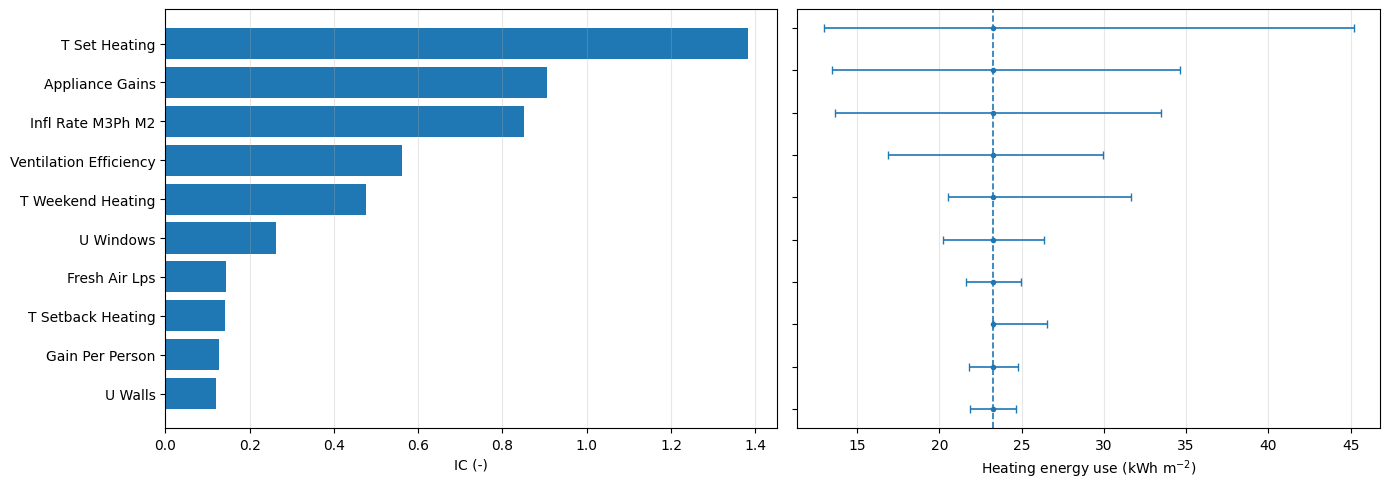

In [15]:
def plot_oat_summary(
    oat_summary,
    metric="heating_eui",
    reference_value=None,
    top_n=10,
    param_labels=None,
    title_left="IC (-)",
    title_right=r"Heating energy use (kWh m$^{-2}$)",
    figsize=(14, 5),
):
    df = oat_summary.copy()

    if param_labels is None:
        param_labels = {}

    baseline_row = df[df["case"] == "baseline"]
    if baseline_row.empty:
        raise ValueError("No baseline row found. Expected case == 'baseline'.")

    baseline_value = baseline_row[metric].iloc[0]
    df_var = df[df["case"].isin(["lower", "upper"])].copy()

    pivot = df_var.pivot_table(
        index="parameter",
        columns="case",
        values=metric,
        aggfunc="first"
    )

    pivot = pivot.dropna(subset=["lower", "upper"]).copy()

    pivot["min_val"] = pivot[["lower", "upper"]].min(axis=1)
    pivot["max_val"] = pivot[["lower", "upper"]].max(axis=1)
    pivot["IC"] = (pivot["max_val"] - pivot["min_val"]) / baseline_value

    pivot["label"] = [
        param_labels.get(p, p.replace("_", " ").title())
        for p in pivot.index
    ]

    plot_df = pivot.sort_values("IC", ascending=False).head(top_n).copy()
    plot_df = plot_df.iloc[::-1]
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=figsize,
        gridspec_kw={"width_ratios": [1.05, 1.0]}
    )

    y = np.arange(len(plot_df))
    ax1.barh(y, plot_df["IC"])
    ax1.set_yticks(y)
    ax1.set_yticklabels(plot_df["label"])
    ax1.set_xlabel(title_left)
    ax1.grid(True, axis="x", alpha=0.3)
    xmin = np.minimum(plot_df["min_val"], baseline_value)
    xmax = np.maximum(plot_df["max_val"], baseline_value)

    xerr_left = baseline_value - xmin
    xerr_right = xmax - baseline_value

    ax2.errorbar(
        x=np.full(len(plot_df), baseline_value),
        y=y,
        xerr=[xerr_left, xerr_right],
        fmt="o",
        capsize=3,
        linewidth=1.2,
        markersize=3,
    )

    ax2.set_yticks(y)
    ax2.set_yticklabels([])
    ax2.set_xlabel(title_right)
    ax2.grid(True, axis="x", alpha=0.3)

    if reference_value is None:
        reference_value = baseline_value

    ax2.axvline(reference_value, linestyle="--", linewidth=1.2)

    plt.tight_layout()
    plt.show()

    return plot_df

plot_df = plot_oat_summary(
    oat_summary=oat_summary,
    metric="heating_eui",
    reference_value=None,
    top_n=10,
    param_labels=None,
    title_left="IC (-)",
    title_right=r"Heating energy use (kWh m$^{-2}$)",
)

In [16]:
def save_top_oat_params_as_uq_json(
    plot_df,
    source_uq_json,
    save_dir,
    output_filename="OAT.json",
    top_n=4,
):
    source_uq_json = Path(source_uq_json)
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    output_path = save_dir / output_filename

    with open(source_uq_json, "r", encoding="utf-8") as f:
        uq_config = json.load(f)

    top_params = (
        plot_df
        .sort_values("IC", ascending=False)
        .head(top_n)
        .index
        .tolist()
    )

    top_config = {
        "N": uq_config["N"],
        "seed": uq_config["seed"],
        "parameters": {}
    }

    for param in top_params:
        if param not in uq_config["parameters"]:
            raise KeyError(
                f"Parameter '{param}' from plot_df was not found in {source_uq_json}"
            )

        top_config["parameters"][param] = uq_config["parameters"][param]

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(top_config, f, indent=2)

    print(f"Saved top-{top_n} OAT UQ JSON to: {output_path}")

    return top_config, output_path

top4_uq_config, top4_uq_path = save_top_oat_params_as_uq_json(
    plot_df=plot_df,
    source_uq_json=Path(uq_path),
    save_dir=save_dir,
    output_filename="OAT.json",
    top_n=4,
)

Saved top-4 OAT UQ JSON to: json\_run\JUN9\OAT.json
